In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('car_fuel_efficiency_2026.txt')
data = data[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

In [27]:
print(data.head())

   engine_displacement  horsepower  vehicle_weight  model_year  \
0                 2180       243.0            3870        2006   
1                 2390       272.0            4210        2008   
2                 2320       267.0            4240        1996   
3                 2130       258.0            4490        1989   
4                 2580       304.0            4510        1994   

   fuel_efficiency_mpg  
0                 31.9  
1                 31.3  
2                 27.5  
3                 28.5  
4                 31.0  


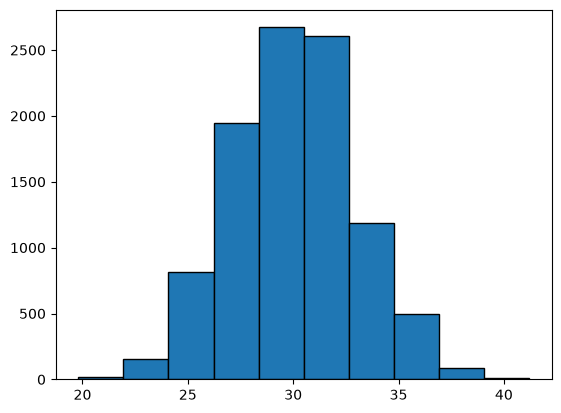

In [30]:
plt.hist(data['fuel_efficiency_mpg'], edgecolor='black')
plt.show()

Relatively normally distributed, no need for logarithmic transformation

## Q1

In [3]:
print(data.isna().sum())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


The column 'horsepower' contains missing values

## Q2

In [4]:
print(data['horsepower'].median())

254.0


The median for horsepower is 254.0

## Q3

In [18]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year']

n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = data.iloc[idx[:n_train]]
df_val = data.iloc[idx[n_train:n_train + n_val]]
df_test = data.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

6252    32.5
4684    29.1
1731    34.1
4742    30.6
4521    30.7
        ... 
7895    29.8
9590    25.1
7288    27.7
278     31.6
3252    28.0
Name: fuel_efficiency_mpg, Length: 6000, dtype: float64


In [19]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [20]:
def prepare_X(df_part, fill_values=None):
    X = df_part[features].copy()
    if fill_values is None:
        return X.fillna(0).values.astype(float)
    else:
        return X.fillna(fill_values).values.astype(float)

In [21]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [22]:
# Fill none with 0
X_train = prepare_X(df_train)

w0, w = train_linear_regression_reg(X_train, y_train, r=0.0)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse_zero = rmse(y_val, y_pred)

In [23]:
# Fill none with mean
df_mean = df_train[features].mean()
X_train = prepare_X(df_train, df_mean)

w0, w = train_linear_regression_reg(X_train, y_train, r=0.0)

X_val = prepare_X(df_val, df_mean)
y_pred = w0 + X_val.dot(w)

rmse_mean = rmse(y_val, y_pred)

In [33]:
print(f'RMSE value with fill 0: {round(rmse_zero,3)}')
print(f'RMSE value with fill mean: {round(rmse_mean,3)}')


RMSE value with fill 0: 2.205
RMSE value with fill mean: 2.202


Since fill mean has an RMSE value lower than fill 0 (2.202 vs 2.205, fill mean gives a better RMSE

## Q4

In [49]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_values =[]
for values in r_values:
    X_train = prepare_X(df_train)
    
    w0, w = train_linear_regression_reg(X_train, y_train, r=values)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    
    rmse_values.append(rmse(y_val, y_pred))
print(f' The smallest RMSE value is: {round(min(rmse_values),4)}')
index = rmse_values.index(min(rmse_values))
print(f' The best r value is: {r_values[index]}')

 The smallest RMSE value is: 2.2067
 The best r value is: 0.01


## Q5

In [45]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_values = []
for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = data.iloc[idx[:n_train]]
    df_val = data.iloc[idx[n_train:n_train + n_val]]
    df_test = data.iloc[idx[n_train + n_val:]]
    
    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    y_test = df_test.fuel_efficiency_mpg
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)

    w0, w = train_linear_regression_reg(X_train, y_train, r=0.0)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    
    rmse_values.append(round(rmse(y_val, y_pred),4))
val_std = np.std(rmse_values)
print(f'std is: {round(val_std,3)}')

std is: 0.029


## Q6

In [54]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = data.iloc[idx[:n_train]]
df_val = data.iloc[idx[n_train:n_train + n_val]]
df_test = data.iloc[idx[n_train + n_val:]]
    
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train)

y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
    
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
rmse_value = rmse(y_test, y_pred)

print(f'The RMSE value on the test dataset is: {round(rmse_value, 3)}')

The RMSE value on the test dataset is: 2.236
